In [4]:
import numpy as np
import sympy
from sympy import symbols, Eq, linear_eq_to_matrix
import random
import matplotlib.pyplot as plt
from collections import deque, defaultdict
# from pyeda.inter import expr, exprvar, expr2bdd
# from dd.autoref import BDD
import networkx as nx
from matplotlib.colors import ListedColormap
import itertools
import pandas as pd
from sympy.logic.boolalg import SOPform
import re
import pickle
import datetime
import time
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from itertools import product
import seaborn as sns
from collections import deque


# change the code to save the data in sqlite database or pickle file to store the results
    # store number of devices in each path
    # Store currents in each path for future plots

#make code run in hipergator

#run upto 3-bit adder for optimal solution with 10 iterations and generate graphs

#############################################################################

#find and pinpoint cases that get only max zeros and min ones current

# 1 - (number of devices)
# 0 - (neighbour lrs devices to ground)
# run the simulation for only those special cases
import sys
import os
import importlib

In [5]:
# Insert the parent directory (one level up) into sys.path:
parent_dir = os.path.abspath("..")  # or an explicit path to the parent
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# First import the module in a normal way:
import PathDesignGeneration

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignGeneration)
from PathDesignGeneration import PATH

In [6]:
# Insert the parent directory (one level up) into sys.path:
parent_dir = os.path.abspath("..")  # or an explicit path to the parent
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# First import the module in a normal way:
import PathDesignGeneration

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignGeneration)
from PathDesignGeneration import PATH


lst= [1,4,8,16,32]
path_design_lst = []

filename_lst = {str(i)+"-bitMultiplexer":"../bdds/Multiplexer/"+str(i)+"-bitMultiplexer.sbdd" for i in lst}
# with open("Data/truth_tables_data.pkl", "rb") as f:
#     truth_tables_data = pickle.load(f)

Functional_Logic_Of_Path_Crossbar_Programings = {}
nadder = 1
for adderbit in lst:
    start_time = time.time()
    adder_index = adderbit-1
    filename = filename_lst[str(adderbit)+'-bitMultiplexer']

    # if(adderbit<10):
    #     outputs, df = truth_tables_data[str(adderbit)+'-bitAdder']["outputs"], truth_tables_data[str(adderbit)+'-bitAdder']["TruthTable_df"]
    # else:
    #     outputs, df = None, None
        
    path = PATH(CrossbarGridSize = 100)
    # path.TruthTable_to_BooleanExpression(df, outputs=outputs)
    # path.BooleanExpresions_to_BDD()
    # print("----------------------------------------------------------------------------------------------")
    # expressions = {'F0' : '(a & b) | (a & cin) | (b & cin)',
    # 'F1' : '(a & b & cin) | (a & ~b & ~cin) | (b & ~a & ~cin) | (cin & ~a & ~b)'}
    # variables = ['a', 'b', 'cin']
    # path.SetBooleanExpressionsAndVaribles(variables = variables, expressions = expressions, outputs = list(expressions.keys()))
    # print("----------------------------------------------------------------------------------------------")
    
    # path.SetBooleanExpressionsAndVaribles(variables = None, expressions = None, outputs = outputs, OriginalTruthTable=df)
    path.parse_file_to_NetworkXGraph(filename)
    path.BDD_to_NetworkXGraph()
    # if(adderbit<5):
    #     path.Verify_BDD_to_NetworkXGraph(withExpression=False, withOriginalTruthTable=False, generateFromBDD=True)
    # path.VisuvaliseNetworkXGraph()
    # print("----------------------------------------------------------------------------------------------")
    path.GraphPreprocessing()
    # if(adderbit==1):
    #     path.VisuvaliseNetworkXGraph()
    # print("----------------------------------------------------------------------------------------------")
    path.GraphTransformation()
    # path.VisuvaliseNetworkXGraph(bipartite=True)
    # print("----------------------------------------------------------------------------------------------")
    path.GraphCompression()
    # if(adderbit==1):
    #     path.VisuvaliseNetworkXGraph(bipartite=True)
    # print("----------------------------------------------------------------------------------------------")

    # path.GraphSplittingWithHeightConstraint(height=10)
    path.GraphSplittingWithHeightConstraint(height=40)

    # path.GraphSplittinWithSizeConstraint(size=64)
    path.GraphSplittinWithSizeConstraint(size=128)
    
    path.CrossbarDesignRelalization()

    path_design_lst.append(path)

    # path.InferPrerequisiteTrees()

    # print('path.Processed_graphs_Map', path.Processed_graphs_Map.keys())

    # print('path.Processed_graphs_Map[None]',path.Processed_graphs_Map[None])

    # print('path.output_node_index',path.output_node_index)

    # rows, cols, count = 0, 0, 0
    # dimMap = {}
    # for key in path.Processed_graphs_Map:
    #     row = len(path.Processed_graphs_Map[key]['Crossbar_design'])
    #     col = len(path.Processed_graphs_Map[key]['Crossbar_design'][0])

    #     if(f'{row}x{col}' not in dimMap):
    #         dimMap[f'{row}x{col}'] = 0
    #     dimMap[f'{row}x{col}']+=1
    #     rows+=row
    #     cols+=col
    #     count+=1

    # print('Total = rows x cols:', rows,"x", cols, "count:", count)
    # print(dimMap)

    # Functional_Logic_Of_Path_Crossbar_Programings[str(adderbit)+'-bitAdder'] = {'Crossbar':path.CrossbarResistiveStates, 'Bitlines':path.Bitlines, 'TruthTable':path.OriginalTruthTable, 'OutputLine_Map':path.OutputLine_Map, 'AdderBit':str(adderbit)+'-bitAdder', 'SBDD (V x E)':path.SBDD_dimentions}
    
    print(f"{adderbit}-bit Adder took {time.time() - start_time:.6f} seconds")

    # print('path.CrossbarLongPaths',path.CrossbarLongPaths)
    print("_________________________________________________________________________")
    # if(adderbit==nadder):
    #     break

# Save (pickle) to a file
# with open("Data/Functional_Logic_Of_Path_Crossbar_Programings.pkl", "wb") as f:
#     pickle.dump(Functional_Logic_Of_Path_Crossbar_Programings, f)
# print("Data saved to multi_data.pkl")

longPath ['1', 'b', '2', 'sel', '4', 'O0']
1-bit Adder took 0.015521 seconds
_________________________________________________________________________
longPath ['1', 'i0', '2', '~sel0', '6', '~sel1', '8', 'O0']
4-bit Adder took 0.017611 seconds
_________________________________________________________________________
longPath ['1', '~sel2', '6', '~i4', '2', 'i0', '8', '~sel0', '16', '~sel1', '18', 'O0']
8-bit Adder took 0.023025 seconds
_________________________________________________________________________
longPath ['1', '~sel3', '10', 'i2', '20', '~i10', '12', 'sel1', '28', '~sel0', '32', '~sel2', '34', 'O0']
16-bit Adder took 0.016107 seconds
_________________________________________________________________________
longPath ['1', '~sel4', '18', 'i6', '36', '~i22', '20', '~sel0', '52', 'sel1', '60', '~sel3', '64', 'sel2', '66', 'O0']
32-bit Adder took 0.024577 seconds
_________________________________________________________________________


In [7]:
path.Topological_order

[(frozenset(), 0)]

In [8]:
for design_ID_group in path.Processed_group_graphs_Map:
    print()
    print(path.Processed_group_graphs_Map[design_ID_group].keys())
    print(sorted(path.Processed_group_graphs_Map[design_ID_group]['OutputLine_group_Map'].keys()))
    print(sorted(path.Processed_group_graphs_Map[design_ID_group]['OutputLine_group_selectorLines_Map'].keys()))
    print(path.Processed_group_graphs_Map[design_ID_group]['OutputLine_group_selectorLines_Map'])


dict_keys(['processed_group_graph', 'OutputLine_group_Map', 'OutputLine_group_selectorLines_Map', 'BDD_dimentions', 'Selector_Lines_Map', 'Crossbar_design', 'DesignIdItemToWordLineInputMap', 'LongestPaths'])
['O0']
['O0']
{'O0': [94, 110, 73, 55, 91, 104, 64, 42, 27, 29, 71, 90, 49, 41, 97, 78, 35, 100, 83, 57, 26, 2, 53, 39, 86, 65, 47, 112, 101, 54, 44, 95, 30, 40, 77, 70, 82, 0, 25, 51, 56, 14, 84, 3, 59, 12, 6, 62, 32, 87, 105, 10, 43, 109, 9, 93, 69, 46, 4, 34, 85, 28, 45, 107, 99, 66, 61, 111, 23, 68, 16, 108, 81, 13, 22, 79, 37, 98, 102, 19, 33, 50, 21, 89, 106, 1, 80, 31, 52, 7, 5, 74, 20, 75, 96, 60, 76, 103, 38, 58, 92, 36, 15, 11, 88, 48, 63, 17, 8, 72, 24, 67, 18]}


In [9]:
# First import the module in a normal way:
import PathDesignLogicalVerification

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignLogicalVerification)
from PathDesignLogicalVerification import PATH_Design_Logic_Verification, Bus

for node in path.Processed_group_graphs_Map:
    # for row in path.Processed_graphs_Map[node]['Crossbar_design']:
    #     print(row)
    # print(path.Processed_graphs_Map[node]['Selector_Lines_Map'])
    # print(path.Processed_graphs_Map[node]['OutputLine_Map'])
    # print()
    # print(path.Processed_graphs_Map[node]['BDD_dimentions'])
    # print(path.Processed_graphs_Map[node]['LongestPath'])
    # print(path.Processed_graphs_Map[node]['DesignIdItemToWordLineInputMap'])
    # print(path.Processed_graphs_Map[node]['PrerequisiteTrees'])
    print('------------------------------------------------')

CrossbarGridSize = 128

for path in path_design_lst:

    bus = Bus(MainBDD_For_GoldenModel = path.Graph, Topological_order = path.Topological_order)
    
    total_rows = 0
    total_cols = 0
    Processed_group_graphs_Map = {}
    for design_ID in path.Processed_group_graphs_Map:
        m = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'])
        n = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'][0])
        if(total_rows+m <= CrossbarGridSize and total_cols+n <= CrossbarGridSize):
            Processed_group_graphs_Map[design_ID] = path.Processed_group_graphs_Map[design_ID]
            total_rows += m
            total_cols += n
        else:
            path_functional_verification = PATH_Design_Logic_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)
            Processed_group_graphs_Map = {design_ID: path.Processed_group_graphs_Map[design_ID]}
    if(len(Processed_group_graphs_Map)):
        path_functional_verification = PATH_Design_Logic_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)
    
    print('NumberOfDesigns:', bus.getNumberOfDesigns())
    print('NumberOfCrossbars:', bus.getNumberOfCrossbars())
    
    test_results = bus.RunRandomTestCases(num_tests=4, RunAllTests=False)
    print('----------------------------------------------')


# OutputLine_group_selectorLines_Map

------------------------------------------------
NumberOfDesigns: 1
NumberOfCrossbars: 1
______________________________________
[✅] Test 1 Passed {'out': 0}
______________________________________
______________________________________
[✅] Test 2 Passed {'out': 0}
______________________________________
______________________________________
[✅] Test 3 Passed {'out': 0}
______________________________________
______________________________________
[✅] Test 4 Passed {'out': 0}
______________________________________
Number of test cases passed out of is 4/4
----------------------------------------------
NumberOfDesigns: 1
NumberOfCrossbars: 1
______________________________________
[✅] Test 1 Passed {'out': 1}
______________________________________
______________________________________
[✅] Test 2 Passed {'out': 1}
______________________________________
______________________________________
[✅] Test 3 Passed {'out': 1}
______________________________________
_________________________________

In [10]:
# First import the module in a normal way:
import PathDesignAnalogVerification

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignAnalogVerification)
from PathDesignAnalogVerification import PATH_Design_Analog_Verification, Bus

for node in path.Processed_group_graphs_Map:
    # for row in path.Processed_graphs_Map[node]['Crossbar_design']:
    #     print(row)
    # print(path.Processed_graphs_Map[node]['Selector_Lines_Map'])
    # print(path.Processed_graphs_Map[node]['OutputLine_Map'])
    # print()
    # print(path.Processed_graphs_Map[node]['BDD_dimentions'])
    # print(path.Processed_graphs_Map[node]['LongestPath'])
    # print(path.Processed_graphs_Map[node]['DesignIdItemToWordLineInputMap'])
    # print(path.Processed_graphs_Map[node]['PrerequisiteTrees'])
    print('------------------------------------------------')

bus_lst = []

for path in path_design_lst:
    CrossbarGridSize = 128
    bus = Bus(MainBDD_For_GoldenModel = path.Graph, Topological_order = path.Topological_order)
    total_rows = 0
    total_cols = 0
    Processed_group_graphs_Map = {}
    for design_ID in path.Processed_group_graphs_Map:
        m = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'])
        n = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'][0])
        if(total_rows+m <= CrossbarGridSize and total_cols+n <= CrossbarGridSize):
            Processed_group_graphs_Map[design_ID] = path.Processed_group_graphs_Map[design_ID]
            total_rows += m
            total_cols += n
        else:
            path_analog_verification = PATH_Design_Analog_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)
            Processed_group_graphs_Map = {design_ID: path.Processed_group_graphs_Map[design_ID]}
    if(len(Processed_group_graphs_Map)):
        path_analog_verification = PATH_Design_Analog_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)

    bus_lst.append(bus)

# bus.CalibrateHRSValues(Optimisation=True)

------------------------------------------------


In [11]:
CurrentFlow0 = []
CurrentFlow1 = []

for bus in bus_lst:
    # test_results = bus.RunRandomTestCases(num_tests=40, RunAllTests=True)
    test_results = bus.RunRandomTestCases(num_tests=10, RunAllTests=False)
    
    failuresOfWorstcase0 = 0
    failuresOfWorstcase1 = 0
    
    currentFlag = False
    for design_ID in bus.OnesCurrentFromDesignMap:
        minOnesCurrent = min(bus.OnesCurrentFromDesignMap[design_ID],default=1)
        maxZerosCurrent = max(bus.ZerosCurrentFromDesignMap[design_ID],default=0)
        print()
        print(f"maxZerosCurrent: {maxZerosCurrent}")
        print(f"minOnesCurrent : {minOnesCurrent}")
        
        CurrentFlow0.append(maxZerosCurrent)
        CurrentFlow1.append(minOnesCurrent)
        
        # if(maxZerosCurrent-bus.WorstCaseMaxZero[design_ID]>1e-4):
        #     print(f"Worst case approximation is not working 0 for {design_ID}")
        #     print(f"{bus.WorstCaseMaxZero[design_ID]} < {maxZerosCurrent}")
        #     print("worst max 0 < current") 
        #     failuresOfWorstcase0+=1
        
        # if(bus.WorstCaseMinOne[design_ID]-minOnesCurrent>1e-4):
        #     print(f"Worst case approximation is not working 1 for {design_ID}")
        #     print(f"{bus.WorstCaseMinOne[design_ID]} > {minOnesCurrent}")
        #     print("worst min 1 > current")
        #     failuresOfWorstcase1+=1
        
        if(minOnesCurrent<maxZerosCurrent):
            currentFlag = True
            print(f'Have an issue at {design_ID}')
    
    if(currentFlag):
        print("\nNot good 😡")
    else:
        print("\ngood 😁")

wordLineInputs [0]
OutputLine_group_Map {'O0': 'out'}
design_ID_group_output {'out': 1}
______________________________________
[✅] Test 1 Passed {'out': 1}
______________________________________
wordLineInputs [0]
OutputLine_group_Map {'O0': 'out'}
design_ID_group_output {'out': 1}
______________________________________
[✅] Test 2 Passed {'out': 1}
______________________________________
wordLineInputs [0]
OutputLine_group_Map {'O0': 'out'}
design_ID_group_output {'out': 1}
______________________________________
[✅] Test 3 Passed {'out': 1}
______________________________________
wordLineInputs [0]
OutputLine_group_Map {'O0': 'out'}
design_ID_group_output {'out': 0}
______________________________________
[✅] Test 4 Passed {'out': 0}
______________________________________
wordLineInputs [0]
OutputLine_group_Map {'O0': 'out'}
design_ID_group_output {'out': 0}
______________________________________
[✅] Test 5 Passed {'out': 0}
______________________________________
wordLineInputs [0]
Output

In [12]:
failuresOfWorstcase0, failuresOfWorstcase1

(0, 0)

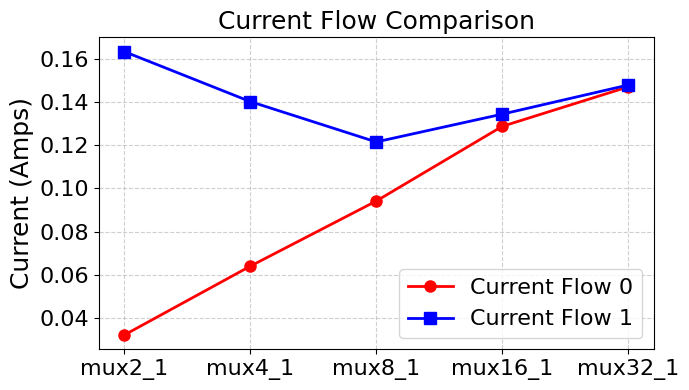

In [13]:
import matplotlib.pyplot as plt

# Create x-axis values
x = ['mux2_1','mux4_1','mux8_1','mux16_1','mux32_1']

# Plotting
plt.figure(figsize=(7, 4))
plt.plot(x, CurrentFlow0, 'o-', color='red', label='Current Flow 0', linewidth=2, markersize=8)
plt.plot(x, CurrentFlow1, 's-', color='blue', label='Current Flow 1', linewidth=2, markersize=8)

# Aesthetics
plt.title('Current Flow Comparison', fontsize=18)
# plt.xlabel('Sample Index', fontsize=14)
plt.ylabel('Current (Amps)', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=16)
plt.tight_layout()

plt.savefig('current_flow_comparison_mux.png', dpi=300, bbox_inches='tight')

plt.show()